In [130]:
import kagglehub
abhikjha_imdb_wiki_faces_dataset_path = kagglehub.dataset_download('abhikjha/imdb-wiki-faces-dataset')

print('Data source import complete.')

Data source import complete.


In [131]:
!cp -r /root/.cache/kagglehub/datasets/abhikjha/imdb-wiki-faces-dataset /content/

^C


### Initial Dataset Review

In [132]:
import scipy.io
import numpy as np

mat = scipy.io.loadmat('/content/imdb-wiki-faces-dataset/versions/2/imdb_crop/imdb.mat')
imdb = mat['imdb'][0][0]

dob = imdb["dob"][0]
photo_taken = imdb["photo_taken"][0]
full_path = imdb["full_path"][0]
gender = imdb["gender"][0]
name = imdb["name"][0]
face_location = imdb["face_location"][0]
face_score = imdb["face_score"][0]
second_face_score = imdb["second_face_score"][0]

ages = photo_taken - (dob / 365.25 + 1970)

In [133]:
import scipy.io

mat = scipy.io.loadmat('/content/imdb-wiki-faces-dataset/versions/2/imdb_crop/imdb.mat')

print("Top-level keys:", mat.keys())

Top-level keys: dict_keys(['__header__', '__version__', '__globals__', 'imdb'])


In [134]:
imdb = mat['imdb'][0, 0]

print("IMDB fields:", imdb.dtype.names)

IMDB fields: ('dob', 'photo_taken', 'full_path', 'gender', 'name', 'face_location', 'face_score', 'second_face_score', 'celeb_names', 'celeb_id')


In [135]:
dob = imdb['dob'][0]
photo_taken = imdb['photo_taken'][0]
gender = imdb['gender'][0]
full_path = imdb['full_path'][0]

print("\nSAMPLE ENTRIES:")
for i in range(5):
    print(f"Entry {i+1}:")
    print(f"  DOB: {dob[i]}")
    print(f"  Photo taken: {photo_taken[i]}")
    print(f"  Gender: {gender[i]}")
    print(f"  Path: {full_path[i][0]}")


SAMPLE ENTRIES:
Entry 1:
  DOB: 693726
  Photo taken: 1968
  Gender: 1.0
  Path: 01/nm0000001_rm124825600_1899-5-10_1968.jpg
Entry 2:
  DOB: 693726
  Photo taken: 1970
  Gender: 1.0
  Path: 01/nm0000001_rm3343756032_1899-5-10_1970.jpg
Entry 3:
  DOB: 693726
  Photo taken: 1968
  Gender: 1.0
  Path: 01/nm0000001_rm577153792_1899-5-10_1968.jpg
Entry 4:
  DOB: 693726
  Photo taken: 1968
  Gender: 1.0
  Path: 01/nm0000001_rm946909184_1899-5-10_1968.jpg
Entry 5:
  DOB: 693726
  Photo taken: 1968
  Gender: 1.0
  Path: 01/nm0000001_rm980463616_1899-5-10_1968.jpg


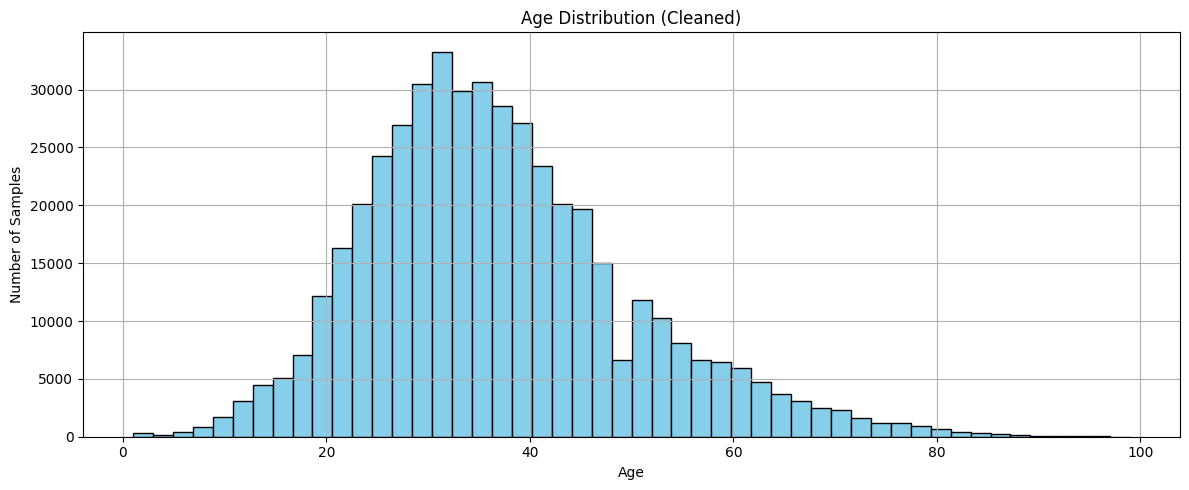

In [136]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

mat = scipy.io.loadmat('/content/imdb-wiki-faces-dataset/versions/2/imdb_crop/imdb.mat')
imdb = mat["imdb"][0, 0]

dob = imdb["dob"][0]
photo_taken = imdb["photo_taken"][0]

def matlab_datenum_to_datetime(matlab_datenum):
    try:
        if np.isnan(matlab_datenum):
            return None
        days = int(matlab_datenum)
        frac = float(matlab_datenum % 1)
        return datetime.fromordinal(days) + timedelta(days=frac) - timedelta(days=366)
    except:
        return None

ages = []
for i in range(len(dob)):
    dob_dt = matlab_datenum_to_datetime(dob[i])
    if dob_dt:
        try:
            age = int(photo_taken[i]) - dob_dt.year
            if 0 < age < 100:
                ages.append(age)
        except:
            continue

plt.figure(figsize=(12, 5))
plt.hist(ages, bins=50, color='skyblue', edgecolor='black')
plt.title("Age Distribution (Cleaned)")
plt.xlabel("Age")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1699281222.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  age_counts = pd.value_counts(age_bins).sort_index()


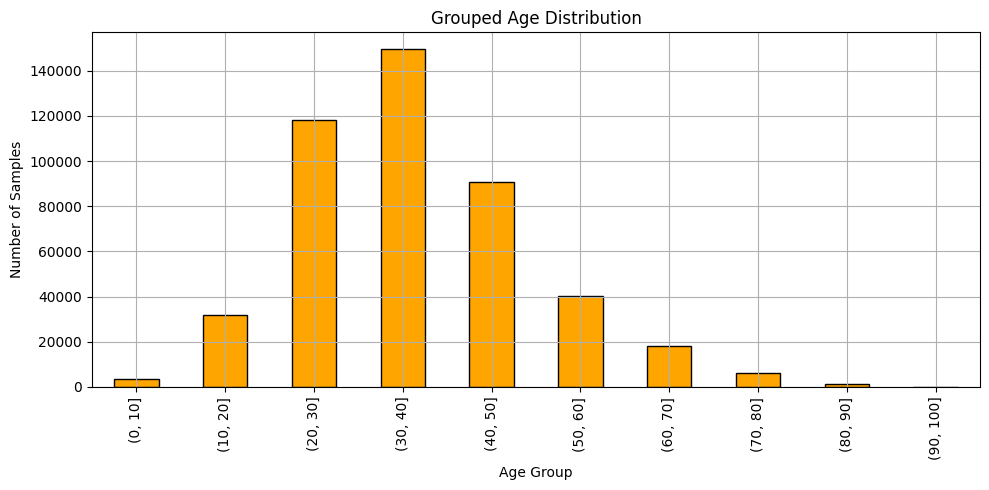

In [137]:
import pandas as pd

age_bins = pd.cut(ages, bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
age_counts = pd.value_counts(age_bins).sort_index()

plt.figure(figsize=(10,5))
age_counts.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Grouped Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.tight_layout()
plt.show()

# Model Training Pipeline

In [138]:
import scipy.io
import numpy as np
import os
import random
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [139]:
def load_mat_dataset(mat_path, dataset_root):
    data = scipy.io.loadmat(mat_path)
    imdb = data['imdb'][0, 0]
    full_path = imdb['full_path'][0]
    dob = imdb['dob'][0]
    photo_taken = imdb['photo_taken'][0]

    ages = photo_taken - (dob / 365.25 + 1970)
    paths = [os.path.join(dataset_root, p[0]) for p in full_path]
    return np.array(paths), ages

In [140]:
def clean_dataset(paths, ages):
    clean_paths, clean_ages = [], []
    for path, age in zip(paths, ages):
        if 0 <= age <= 100 and os.path.exists(path):
            clean_paths.append(path)
            clean_ages.append(age)
    return np.array(clean_paths), np.array(clean_ages)

In [141]:
def balance_age_data(paths, ages, bin_size=10, samples_per_bin=500):
    bins = list(range(0, 101, bin_size))
    selected_paths, selected_ages = [], []

    for i in range(len(bins) - 1):
        bin_mask = (ages >= bins[i]) & (ages < bins[i+1])
        bin_paths = paths[bin_mask]
        bin_ages = ages[bin_mask]

        if len(bin_paths) > samples_per_bin:
            indices = random.sample(range(len(bin_paths)), samples_per_bin)
            bin_paths = bin_paths[indices]
            bin_ages = bin_ages[indices]

        selected_paths.extend(bin_paths)
        selected_ages.extend(bin_ages)

    return np.array(selected_paths), np.array(selected_ages)

In [142]:
from PIL import Image

class AgeDataGenerator(Sequence):
    def __init__(self, image_paths, ages, batch_size=32, img_size=(128, 128), shuffle=True):
        self.image_paths = image_paths
        self.ages = ages
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_ages = self.ages[idx * self.batch_size:(idx + 1) * self.batch_size]

        images = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                img = img.resize(self.img_size)
                img = np.array(img)
                img = preprocess_input(img)
                images.append(img)
            except:
                continue

        return np.array(images), np.array(batch_ages)

    def on_epoch_end(self):
        if self.shuffle:
            temp = list(zip(self.image_paths, self.ages))
            random.shuffle(temp)
            self.image_paths, self.ages = zip(*temp)
            self.image_paths = np.array(self.image_paths)
            self.ages = np.array(self.ages)

In [143]:
def build_mobilenet_model(input_shape=(128, 128, 3)):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='linear')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [144]:
def train_model(model, train_gen, val_gen, epochs=100):
    print("📊 Model Summary:")
    model_summary = model.summary()
    optimizer = 'adam'
    loss_fn = 'mse'
    metrics_list = ['mae']

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=metrics_list
    )

    lr_scheduler = ReduceLROnPlateau(
        patience=3,
        factor=0.5,
        verbose=1
    )

    callbacks_list = [lr_scheduler]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks_list
    )

    return history

In [146]:
mat_path = '/content/imdb-wiki-faces-dataset/versions/2/imdb_crop/imdb.mat'
dataset_root = '/content/imdb-wiki-faces-dataset/versions/2/imdb_crop'

# Load and prepare
paths, ages = load_mat_dataset(mat_path, dataset_root)
paths, ages = clean_dataset(paths, ages)
paths, ages = balance_age_data(paths, ages)

# Split
from sklearn.model_selection import train_test_split
train_paths, val_paths, train_ages, val_ages = train_test_split(paths, ages, test_size=0.2, random_state=42)

# Generators
train_gen = AgeDataGenerator(train_paths, train_ages, batch_size=32)
val_gen = AgeDataGenerator(val_paths, val_ages, batch_size=32, shuffle=False)

# Build model
model = build_mobilenet_model()

# Train
train_model(model, train_gen, val_gen)

📊 Model Summary:


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 1253.2137 - mae: 34.5820 - val_loss: 549.7368 - val_mae: 22.5001 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - loss: 517.3864 - mae: 21.2274 - val_loss: 122.5275 - val_mae: 9.6037 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step - loss: 114.7751 - mae: 9.5301 - val_loss: 91.6620 - val_mae: 7.8984 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - loss: 135.8350 - mae: 8.7524 - val_loss: 178.4608 - val_mae: 11.5435 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 601ms/step - loss: 164.1235 - mae: 10.1185 - val_loss: 163.6615 - val_mae: 11.0443 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step - loss: 165.6418 - mae: 9.6811 - val_loss: 86.1453 - val_mae: 7.6762 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - loss: 89.1031 - mae: 7.0557 - val_loss: 60.8980 - val_mae: 5.7260 - learni